In [2]:
!pip install -U transformers datasets accelerate scikit-learn pandas matplotlib seaborn torch

  Using cached transformers-5.15.0-py3-none-any.whl.metadata (32 kB)
  Using cached datasets-5.0.1-py3-none-any.whl.metadata (23 kB)
  Using cached accelerate-1.14.0-py3-none-any.whl.metadata (19 kB)
  Using cached pandas-3.0.5-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached torch-2.13.0-cp312-cp312-win_amd64.whl.metadata (39 kB)
  Using cached huggingface_hub-1.27.0-py3-none-any.whl.metadata (16 kB)
  Using cached regex-2026.7.19-cp312-cp312-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached typer-0.27.1-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.8.0-cp310-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached tqdm-4.70.0-py3-none-any.whl.metadata (57 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached filelock-3.32.3-py3-

  Using cached transformers-5.15.0-py3-none-any.whl.metadata (32 kB)
  Using cached datasets-5.0.1-py3-none-any.whl.metadata (23 kB)
Using cached transformers-5.15.0-py3-none-any.whl (11.7 MB)
Using cached datasets-5.0.1-py3-none-any.whl (559 kB)

   ---------------------------------------- 0/2 [datasets]
   ---------------------------------------- 0/2 [datasets]
   ---------------------------------------- 0/2 [datasets]
   ---------------------------------------- 0/2 [datasets]
   ---------------------------------------- 0/2 [datasets]
   ---------------------------------------- 0/2 [datasets]
   ---------------------------------------- 0/2 [datasets]
   ---------------------------------------- 0/2 [datasets]
   ---------------------------------------- 0/2 [datasets]
   ---------------------------------------- 0/2 [datasets]
   -------------------- ------------------- 1/2 [transformers]
   -------------------- ------------------- 1/2 [transformers]
   -------------------- ------------

In [3]:
pip show pyarrow

Name: pyarrow
Version: 24.0.0
Summary: Python library for Apache Arrow
Home-page: https://arrow.apache.org/
Author: 
Author-email: 
License-Expression: Apache-2.0
Location: c:\Users\raich\anaconda3\envs\major_env\Lib\site-packages
Requires: 
Required-by: datasets
Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
print(sys.executable)

import pyarrow
print(pyarrow.__file__)
print(getattr(pyarrow, "__version__", "NO VERSION"))

c:\Users\raich\anaconda3\envs\major_env\python.exe
c:\Users\raich\anaconda3\envs\major_env\Lib\site-packages\pyarrow\__init__.py
24.0.0


In [ ]:
pip install pandas pyarrow

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: pandas in c:\users\raich\anaconda3\lib\site-packages (3.0.5)



In [5]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from torch import nn
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    TrainerCallback,
    set_seed
)

from datasets import Dataset

In [6]:
try:
    BASE_DIR = os.path.dirname(
        os.path.dirname(os.path.abspath(__file__))
    )
except NameError:
    BASE_DIR = os.getcwd()

PROCESSED = os.path.join(
    BASE_DIR,
    "data",
    "processed"
)

OUTPUT = os.path.join(
    BASE_DIR,
    "outputs",
    "security_classifier"
)

MODEL_OUTPUT = os.path.join(
    OUTPUT,
    "best_model"
)

TOKENIZER_OUTPUT = os.path.join(
    OUTPUT,
    "tokenizer"
)

os.makedirs(OUTPUT, exist_ok=True)
os.makedirs(MODEL_OUTPUT, exist_ok=True)
os.makedirs(TOKENIZER_OUTPUT, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Processed:", PROCESSED)
print("Output:", OUTPUT)

Base directory: c:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\notebooks
Processed: c:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\notebooks\data\processed
Output: c:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\notebooks\outputs\security_classifier


In [7]:
SEED = 42

set_seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed:", SEED)

Seed: 42


In [11]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path(r"C:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation")

PROCESSED = PROJECT_ROOT / "data" / "processed"

train_df = pd.read_csv(
    os.path.join(
        PROCESSED,
        "security_train_processed.csv"
    )
)

validation_df = pd.read_csv(
    os.path.join(
        PROCESSED,
        "security_validation_processed.csv"
    )
)

test_df = pd.read_csv(
    os.path.join(
        PROCESSED,
        "security_test_processed.csv"
    )
)

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

Train: (10059, 9)
Validation: (2306, 7)
Test: (2306, 7)


In [12]:
print(train_df.columns.tolist())

['prompt', 'attack_type', 'severity', 'is_safe', 'phi_present', 'source_dataset', 'label', 'characters', 'words']


In [13]:
print("Train missing prompts:",
      train_df["prompt"].isna().sum())

print("Validation missing prompts:",
      validation_df["prompt"].isna().sum())

print("Test missing prompts:",
      test_df["prompt"].isna().sum())

Train missing prompts: 0
Validation missing prompts: 0
Test missing prompts: 0


In [14]:
print("Training Distribution")
print(train_df["attack_type"].value_counts())

print("\nValidation Distribution")
print(validation_df["attack_type"].value_counts())

print("\nTest Distribution")
print(test_df["attack_type"].value_counts())

Training Distribution
attack_type
safe          5627
malicious     2874
phi            718
suspicious     661
jailbreak      179
Name: count, dtype: int64

Validation Distribution
attack_type
safe          1681
malicious      356
suspicious      96
phi             96
jailbreak       77
Name: count, dtype: int64

Test Distribution
attack_type
safe          1660
malicious      383
phi             98
suspicious      93
jailbreak       72
Name: count, dtype: int64


In [17]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path(r"C:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation")

label_mapping = pd.read_csv(
    BASE_DIR / "outputs" / "tokenized" / "label_mapping.csv"
)

label_mapping

,Class,Encoded Label
0,jailbreak,0
1,malicious,1
2,phi,2
3,safe,3
4,suspicious,4


In [18]:
label2id = dict(
    zip(
        label_mapping["Class"],
        label_mapping["Encoded Label"]
    )
)

id2label = {
    int(v): k
    for k, v in label2id.items()
}

print("label2id:")
print(label2id)

print("\nid2label:")
print(id2label)

label2id:
{'jailbreak': 0, 'malicious': 1, 'phi': 2, 'safe': 3, 'suspicious': 4}

id2label:
{0: 'jailbreak', 1: 'malicious', 2: 'phi', 3: 'safe', 4: 'suspicious'}


In [19]:
print(
    "Unique training labels:",
    sorted(train_df["label"].unique())
)

print(
    "Expected labels:",
    sorted(id2label.keys())
)

Unique training labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Expected labels: [0, 1, 2, 3, 4]


In [20]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded:", MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

c:\Users\raich\anaconda3\envs\major_env\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\raich\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Tokenizer loaded: distilbert-base-uncased


In [21]:
token_lengths = train_df["prompt"].apply(
    lambda x: len(
        tokenizer(
            str(x),
            truncation=False,
            add_special_tokens=True
        )["input_ids"]
    )
)

token_lengths.describe()

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (675 > 512). Running this sequence through the model will result in indexing errors


count    10059.000000
mean       142.228552
std        112.451406
min          3.000000
25%         49.000000
50%        130.000000
75%        203.000000
max        794.000000
Name: prompt, dtype: float64

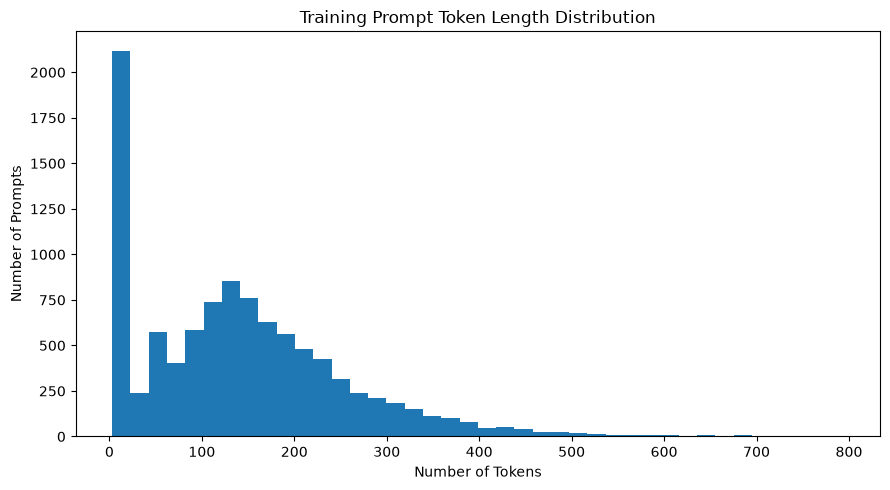

In [22]:
plt.figure(figsize=(9, 5))

plt.hist(
    token_lengths,
    bins=40
)

plt.xlabel("Number of Tokens")
plt.ylabel("Number of Prompts")
plt.title("Training Prompt Token Length Distribution")

plt.tight_layout()

plt.show()

In [23]:
train_dataset = Dataset.from_pandas(
    train_df[
        ["prompt", "label"]
    ],
    preserve_index=False
)

validation_dataset = Dataset.from_pandas(
    validation_df[
        ["prompt", "label"]
    ],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[
        ["prompt", "label"]
    ],
    preserve_index=False
)

print(train_dataset)

Dataset({
    features: ['prompt', 'label'],
    num_rows: 10059
})


In [26]:
MAX_LENGTH = 256
def tokenize_function(examples):

    return tokenizer(
        examples["prompt"],
        truncation=True,
        max_length=MAX_LENGTH
    )

In [27]:
train_dataset = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["prompt"]
)

validation_dataset = validation_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["prompt"]
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["prompt"]
)

Map:   0%|          | 0/10059 [00:00<?, ? examples/s]

Map:   0%|          | 0/2306 [00:00<?, ? examples/s]

Map:   0%|          | 0/2306 [00:00<?, ? examples/s]

In [28]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [29]:
class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

num_classes = len(label2id)

total_samples = len(train_df)

class_weights = total_samples / (
    num_classes * class_counts
)

class_weights = class_weights.sort_index()

print("Class counts:")
print(class_counts)

print("\nClass weights:")
print(class_weights)

Class counts:
label
0    5627
1    2874
2     718
3     179
4     661
Name: count, dtype: int64

Class weights:
label
0     0.357526
1     0.700000
2     2.801950
3    11.239106
4     3.043570
Name: count, dtype: float64


In [30]:
class_weights_tensor = torch.tensor(
    class_weights.values,
    dtype=torch.float
)

class_weights_tensor

tensor([ 0.3575,  0.7000,  2.8019, 11.2391,  3.0436])

In [31]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
)

print("Model loaded.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.


In [32]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    precision_weighted, recall_weighted, f1_weighted, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }

In [33]:
class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):

        labels = inputs.get("labels")

        outputs = model(
            **inputs
        )

        logits = outputs.get("logits")

        weights = class_weights_tensor.to(
            logits.device
        )

        loss_function = nn.CrossEntropyLoss(
            weight=weights
        )

        loss = loss_function(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (
            loss,
            outputs
        ) if return_outputs else loss

In [34]:
training_args = TrainingArguments(

    output_dir=OUTPUT,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=32,

    num_train_epochs=4,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1_macro",

    greater_is_better=True,

    save_total_limit=2,

    report_to="none",

    fp16=torch.cuda.is_available(),

    seed=SEED
)

In [35]:
trainer = WeightedTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=validation_dataset,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [36]:
train_result = trainer.train()

c:\Users\raich\anaconda3\envs\major_env\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.553939,0.263021,0.904163,0.830936,0.874728,0.840120,0.930675,0.904163,0.914228
2,0.376412,0.269577,0.932784,0.863328,0.860950,0.862089,0.932220,0.932784,0.932488
3,0.305322,0.287044,0.924545,0.844271,0.858553,0.850883,0.928077,0.924545,0.925815
4,0.250826,0.354888,0.931483,0.866490,0.838406,0.846461,0.927768,0.931483,0.928137


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\raich\anaconda3\envs\major_env\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\raich\anaconda3\envs\major_env\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\raich\anaconda3\envs\major_env\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [37]:
validation_results = trainer.evaluate(
    validation_dataset
)

validation_results

c:\Users\raich\anaconda3\envs\major_env\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
0.250826,0.269577,4,0.932784,0.863328,0.860950,0.862089,0.932220,0.932784,0.932488


{'eval_loss': 0.26957687735557556,
 'eval_accuracy': 0.9327840416305291,
 'eval_precision_macro': 0.8633283184899717,
 'eval_recall_macro': 0.8609499734864435,
 'eval_f1_macro': 0.8620886078052769,
 'eval_precision_weighted': 0.932219875896108,
 'eval_recall_weighted': 0.9327840416305291,
 'eval_f1_weighted': 0.9324884803790937}

In [38]:
trainer.save_model(
    MODEL_OUTPUT
)

tokenizer.save_pretrained(
    TOKENIZER_OUTPUT
)

print("Best model saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved.


In [39]:
trainer.save_model(
    MODEL_OUTPUT
)

tokenizer.save_pretrained(
    TOKENIZER_OUTPUT
)

print("Best model saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved.


In [40]:
history = pd.DataFrame(
    trainer.state.log_history
)

history

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision_macro,eval_recall_macro,eval_f1_macro,...,eval_recall_weighted,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.553939,4.286296,1.500795e-05,1.0,629,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,629,0.263021,0.904163,0.830936,0.874728,0.840120,...,0.904163,0.914228,386.0093,5.974,0.189,NaN,NaN,NaN,NaN,NaN
2,0.376412,16.753958,1.000795e-05,2.0,1258,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,1258,0.269577,0.932784,0.863328,0.860950,0.862089,...,0.932784,0.932488,387.6195,5.949,0.188,NaN,NaN,NaN,NaN,NaN
4,0.305322,1.336213,5.007949e-06,3.0,1887,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,1887,0.287044,0.924545,0.844271,0.858553,0.850883,...,0.924545,0.925815,366.4557,6.293,0.199,NaN,NaN,NaN,NaN,NaN
6,0.250826,2.336468,7.949126e-09,4.0,2516,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,4.0,2516,0.354888,0.931483,0.866490,0.838406,0.846461,...,0.931483,0.928137,336.2035,6.859,0.217,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,4.0,2516,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,35328.3679,1.139,0.071,2.641301e+15,0.371625
9,NaN,NaN,NaN,4.0,2516,0.269577,0.932784,0.863328,0.860950,0.862089,...,0.932784,0.932488,336.8619,6.846,0.217,NaN,NaN,NaN,NaN,NaN


In [46]:
history.to_csv(
    os.path.join(
        OUTPUT,
        "training_history.csv"
    ),
    index=False
)

print("Training history saved.")

Training history saved.


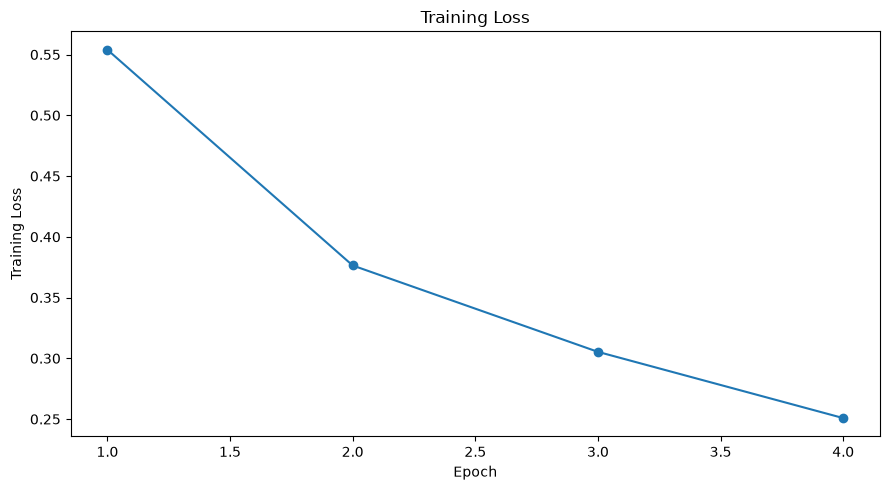

In [42]:
loss_history = history[
    history["loss"].notna()
]

plt.figure(figsize=(9, 5))

plt.plot(
    loss_history["epoch"],
    loss_history["loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT,
        "training_loss.png"
    ),
    dpi=300
)

plt.show()

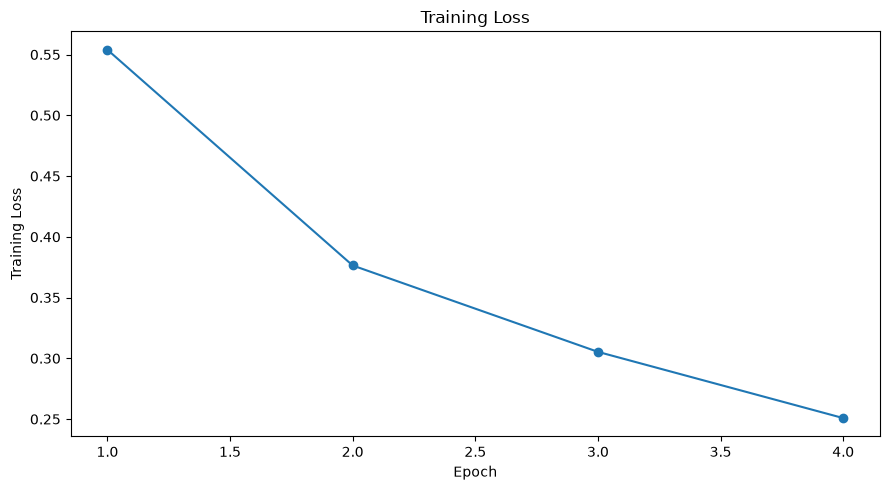

In [43]:
loss_history = history[
    history["loss"].notna()
]

plt.figure(figsize=(9, 5))

plt.plot(
    loss_history["epoch"],
    loss_history["loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT,
        "training_loss.png"
    ),
    dpi=300
)

plt.show()

In [47]:
# Get evaluation history from Hugging Face Trainer
eval_history = [
    log for log in trainer.state.log_history
    if "eval_accuracy" in log
]

print(eval_history)

[{'eval_loss': 0.26302120089530945, 'eval_accuracy': 0.9041630529054641, 'eval_precision_macro': 0.830935583644267, 'eval_recall_macro': 0.874728472774588, 'eval_f1_macro': 0.8401203144733295, 'eval_precision_weighted': 0.9306749357340539, 'eval_recall_weighted': 0.9041630529054641, 'eval_f1_weighted': 0.9142284599818191, 'eval_runtime': 386.0093, 'eval_samples_per_second': 5.974, 'eval_steps_per_second': 0.189, 'epoch': 1.0, 'step': 629}, {'eval_loss': 0.26957687735557556, 'eval_accuracy': 0.9327840416305291, 'eval_precision_macro': 0.8633283184899717, 'eval_recall_macro': 0.8609499734864435, 'eval_f1_macro': 0.8620886078052769, 'eval_precision_weighted': 0.932219875896108, 'eval_recall_weighted': 0.9327840416305291, 'eval_f1_weighted': 0.9324884803790937, 'eval_runtime': 387.6195, 'eval_samples_per_second': 5.949, 'eval_steps_per_second': 0.188, 'epoch': 2.0, 'step': 1258}, {'eval_loss': 0.2870441675186157, 'eval_accuracy': 0.9245446660884649, 'eval_precision_macro': 0.84427107370493

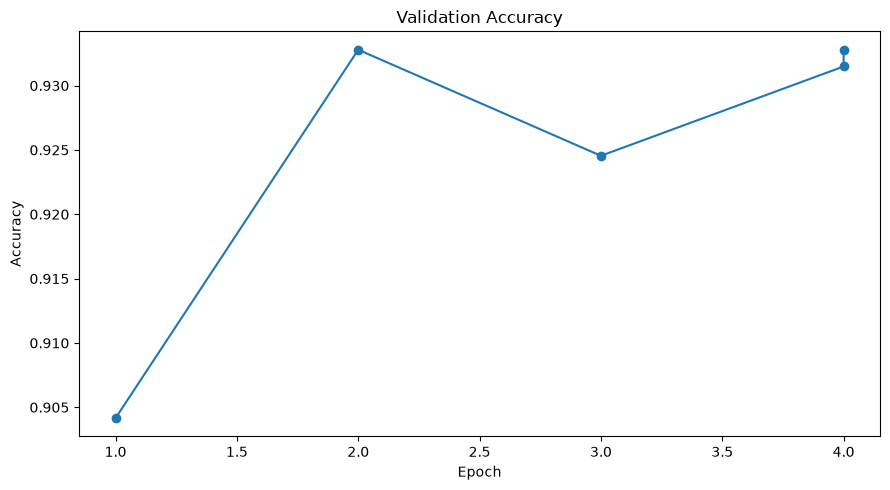

In [48]:
plt.figure(figsize=(9, 5))

plt.plot(
    [log["epoch"] for log in eval_history],
    [log["eval_accuracy"] for log in eval_history],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT,
        "validation_accuracy.png"
    ),
    dpi=300
)

plt.show()

In [51]:
best_f1 = max(
    [log["eval_f1_macro"] for log in eval_history]
)

best_accuracy = max(
    [log["eval_accuracy"] for log in eval_history]
)

summary = f"""
========================================
SECURITY CLASSIFIER TRAINING SUMMARY
========================================

Model:
{MODEL_NAME}

Maximum Sequence Length:
{MAX_LENGTH}

Training Samples:
{len(train_df)}

Validation Samples:
{len(validation_df)}

Test Samples:
{len(test_df)}

Number of Classes:
{num_classes}

Epochs:
{training_args.num_train_epochs}

Learning Rate:
{training_args.learning_rate}

Batch Size:
{training_args.per_device_train_batch_size}

Best Validation Macro F1:
{best_f1:.4f}

Best Validation Accuracy:
{best_accuracy:.4f}

Classes:
{id2label}

========================================
"""

print(summary)

with open(
    os.path.join(
        OUTPUT,
        "training_summary.txt"
    ),
    "w",
    encoding="utf-8"
) as f:

    f.write(summary)


SECURITY CLASSIFIER TRAINING SUMMARY

Model:
distilbert-base-uncased

Maximum Sequence Length:
256

Training Samples:
10059

Validation Samples:
2306

Test Samples:
2306

Number of Classes:
5

Epochs:
4

Learning Rate:
2e-05

Batch Size:
16

Best Validation Macro F1:
0.8621

Best Validation Accuracy:
0.9328

Classes:
{0: 'jailbreak', 1: 'malicious', 2: 'phi', 3: 'safe', 4: 'suspicious'}




In [52]:
print("Training completed.")

print("\nOutput files:")

for root, dirs, files in os.walk(OUTPUT):

    for file in files:

        print(
            os.path.join(
                root,
                file
            )
        )

Training completed.

Output files:
c:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\notebooks\outputs\security_classifier\training_history.csv
c:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\notebooks\outputs\security_classifier\training_loss.png
c:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\notebooks\outputs\security_classifier\training_summary.txt
c:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\notebooks\outputs\security_classifier\validation_accuracy.png
c:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\notebooks\outputs\security_classifier\best_model\config.json
c:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\notebooks\outputs\security_classifier\best_model\model.safetensors
c:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\notebooks\outputs\security_classifier\best_model\tokenizer.json
c:\Users\raich\Desktop\major\Healthcare_Dataset_Preparation\notebooks\outputs\security_classifier\best_model\tokenize